# Exoplanet Classification: Terrestrial vs. Gas Giant

Binary classification of exoplanets into `terrestrial` or `gas_giant` from
five bulk and stellar host parameters: `mass`, `radius`, `orbital_period`,
`star_mass`, `star_radius`, `star_teff`.

The dataset is imbalanced (detection bias favors large, easy-to-find gas
giants), so this notebook uses `class_weight='balanced'` and reports
minority-class precision/recall/F1 alongside accuracy, rather than accuracy
alone.


In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42

# Palette (fixed categorical order, colorblind-safe): slot 1 = blue, slot 2 = orange
COLOR_TERRESTRIAL = "#eb6834"  # minority class -> categorical slot 2
COLOR_GAS_GIANT = "#2a78d6"  # majority class -> categorical slot 1
SEQ_BLUE = ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95"]  # sequential ramp, light->dark

sns.set_style("whitegrid", {"grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["text.color"] = "#0b0b0b"
plt.rcParams["axes.labelcolor"] = "#0b0b0b"

## 1. Load and inspect the data

In [2]:
df = pd.read_csv("exoplanets_clean.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (623, 7)


,mass,radius,orbital_period,star_mass,star_radius,star_teff,planet_type
0,30.00000,0.970000,4640.000000,0.120,0.089,2205.0,gas_giant
1,20.00000,0.920000,7340.000000,0.080,0.100,2300.0,gas_giant
2,30.00000,1.300000,8686.000000,0.130,0.110,2350.0,gas_giant
3,0.47000,1.900000,4.230800,1.110,1.266,5793.0,gas_giant
4,0.02547,0.177536,0.736548,0.905,0.943,5196.0,terrestrial


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 623 entries, 0 to 622
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mass            623 non-null    float64
 1   radius          623 non-null    float64
 2   orbital_period  623 non-null    float64
 3   star_mass       623 non-null    float64
 4   star_radius     623 non-null    float64
 5   star_teff       623 non-null    float64
 6   planet_type     623 non-null    str    
dtypes: float64(6), str(1)
memory usage: 34.2 KB


In [4]:
df.describe()

,mass,radius,orbital_period,star_mass,star_radius,star_teff
count,623.000000,623.000000,623.000000,623.000000,623.000000,623.000000
mean,1.752689,0.860601,168.920836,1.023301,1.160326,5605.783307
std,5.061536,0.533416,2213.923937,0.314113,0.556004,1542.109992
min,0.000063,0.028549,0.176891,0.019000,0.089000,575.000000
25%,0.051293,0.260500,2.980896,0.886500,0.870000,5283.500000
50%,0.569000,1.008000,4.437964,1.022000,1.073000,5715.000000
75%,1.360000,1.281000,11.457095,1.205500,1.429000,6050.000000
max,62.140000,2.085000,47400.000000,2.820000,6.300000,27730.000000


In [5]:
# No missing values in this cleaned dataset, but this check is cheap insurance
# in case the CSV is regenerated or swapped for a rawer extract later.
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "None")

Missing values per column:
None


## 2. Class imbalance

The target is dominated by gas giants: large planets on short orbits are far
easier to detect (transit depth, radial-velocity amplitude) than small
terrestrial planets, so the raw class frequencies reflect detection bias, not
the true occurrence rate of planet types.


gas_giant   :  537  ( 86.2%)
terrestrial :   86  ( 13.8%)


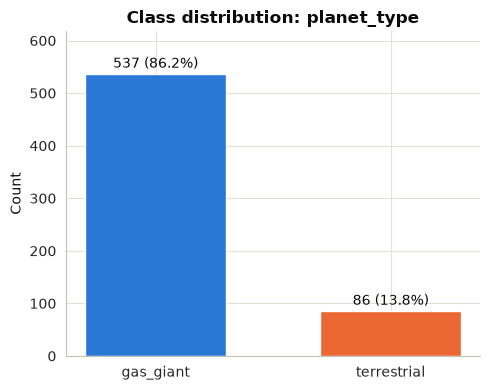

In [6]:
class_counts = df["planet_type"].value_counts()
class_pct = df["planet_type"].value_counts(normalize=True) * 100

for label, count, pct in zip(class_counts.index, class_counts, class_pct, strict=True):
    print(f"{label:12s}: {count:4d}  ({pct:5.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
colors = [COLOR_GAS_GIANT if l == "gas_giant" else COLOR_TERRESTRIAL for l in class_counts.index]
bars = ax.bar(class_counts.index, class_counts.values, color=colors, width=0.6)
for bar, count, pct in zip(bars, class_counts.values, class_pct.values, strict=True):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{count} ({pct:.1f}%)",
        ha="center",
        va="bottom",
        color="#0b0b0b",
    )
ax.set_ylabel("Count")
ax.set_title("Class distribution: planet_type")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, class_counts.max() * 1.15)
plt.tight_layout()
plt.show()

## 3. Train/test split (80/20, stratified)

Stratifying on `planet_type` keeps the ~86/14 class ratio identical in both
splits, so the test set stays representative of the imbalance instead of
randomly over- or under-sampling the minority class.


In [7]:
FEATURES = ["mass", "radius", "orbital_period", "star_mass", "star_radius", "star_teff"]
TARGET = "planet_type"

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print("\nTrain class balance:")
print(y_train.value_counts(normalize=True).round(3))
print("\nTest class balance:")
print(y_test.value_counts(normalize=True).round(3))

Train: 498 rows  |  Test: 125 rows

Train class balance:
planet_type
gas_giant      0.861
terrestrial    0.139
Name: proportion, dtype: float64

Test class balance:
planet_type
gas_giant      0.864
terrestrial    0.136
Name: proportion, dtype: float64


## 4. Models

Three classifiers, each with `class_weight='balanced'` so the minority class
(`terrestrial`) contributes proportionally more to the loss instead of being
swamped by gas giants. Logistic Regression and SVM are wrapped in a
`Pipeline` with `StandardScaler`, since both are distance/gradient based and
sensitive to feature scale (`orbital_period` and `star_teff` span several
orders of magnitude more than `radius`). Random Forest is scale-invariant, so
it trains on the raw features.


In [8]:
models = {
    "Logistic Regression": Pipeline(
        [
            ("scaler", StandardScaler()),
            (
                "clf",
                LogisticRegression(
                    class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000
                ),
            ),
        ]
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", n_estimators=300, random_state=RANDOM_STATE
    ),
    "SVM (RBF)": Pipeline(
        [
            ("scaler", StandardScaler()),
            ("clf", SVC(class_weight="balanced", kernel="rbf", random_state=RANDOM_STATE)),
        ]
    ),
}

fitted_models = {}
predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    fitted_models[name] = model
    predictions[name] = model.predict(X_test)
    print(f"Trained: {name}")

Trained: Logistic Regression


Trained: Random Forest
Trained: SVM (RBF)


## 5. Metrics

Precision, recall, and F1 are computed for the **minority class
(`terrestrial`)**: under an 86/14 imbalance, a classifier that always
predicts `gas_giant` scores ~86% accuracy while never finding a single
terrestrial planet. Reporting the minority-class scores (alongside overall
accuracy) exposes that failure mode; accuracy alone would hide it.


In [9]:
POS_LABEL = "terrestrial"

results = []
for name, y_pred in predictions.items():
    results.append(
        {
            "Model": name,
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision (terrestrial)": precision_score(y_test, y_pred, pos_label=POS_LABEL),
            "Recall (terrestrial)": recall_score(y_test, y_pred, pos_label=POS_LABEL),
            "F1 (terrestrial)": f1_score(y_test, y_pred, pos_label=POS_LABEL),
        }
    )

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df

,Accuracy,Precision (terrestrial),Recall (terrestrial),F1 (terrestrial)
Model,,,,
Logistic Regression,0.896,0.567,1.0,0.723
Random Forest,1.000,1.000,1.0,1.000
SVM (RBF),0.864,0.500,1.0,0.667


In [10]:
for name, y_pred in predictions.items():
    print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
    print(classification_report(y_test, y_pred, digits=3))


Logistic Regression
              precision    recall  f1-score   support

   gas_giant      1.000     0.880     0.936       108
 terrestrial      0.567     1.000     0.723        17

    accuracy                          0.896       125
   macro avg      0.783     0.940     0.830       125
weighted avg      0.941     0.896     0.907       125


Random Forest
              precision    recall  f1-score   support

   gas_giant      1.000     1.000     1.000       108
 terrestrial      1.000     1.000     1.000        17

    accuracy                          1.000       125
   macro avg      1.000     1.000     1.000       125
weighted avg      1.000     1.000     1.000       125


SVM (RBF)
              precision    recall  f1-score   support

   gas_giant      1.000     0.843     0.915       108
 terrestrial      0.500     1.000     0.667        17

    accuracy                          0.864       125
   macro avg      0.750     0.921     0.791       125
weighted avg      0.932    

## 6. Confusion matrices

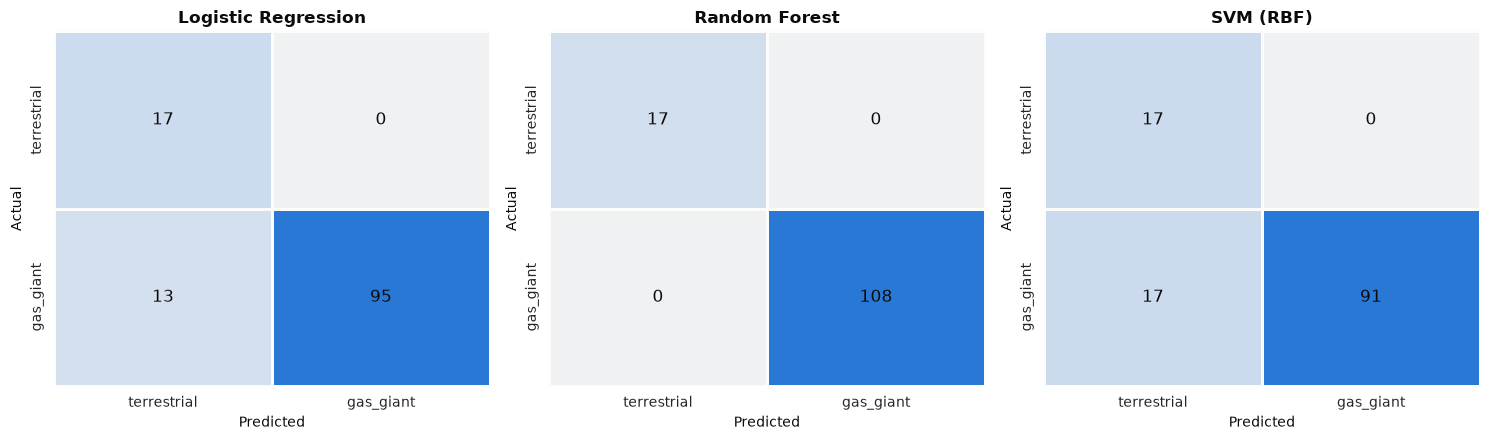

In [11]:
labels_order = ["terrestrial", "gas_giant"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (name, y_pred) in zip(axes, predictions.items(), strict=True):
    cm = confusion_matrix(y_test, y_pred, labels=labels_order)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=sns.light_palette(SEQ_BLUE[2], as_cmap=True),
        xticklabels=labels_order,
        yticklabels=labels_order,
        cbar=False,
        ax=ax,
        annot_kws={"color": "#0b0b0b", "size": 12},
        linewidths=1,
        linecolor="#fcfcfb",
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 7. Model comparison

Table and grouped bar chart of the four metrics side by side.


In [12]:
results_df.style.background_gradient(cmap="Blues", axis=0).format("{:.3f}")

,Accuracy,Precision (terrestrial),Recall (terrestrial),F1 (terrestrial)
Model,,,,
Logistic Regression,0.896,0.567,1.000,0.723
Random Forest,1.000,1.000,1.000,1.000
SVM (RBF),0.864,0.500,1.000,0.667


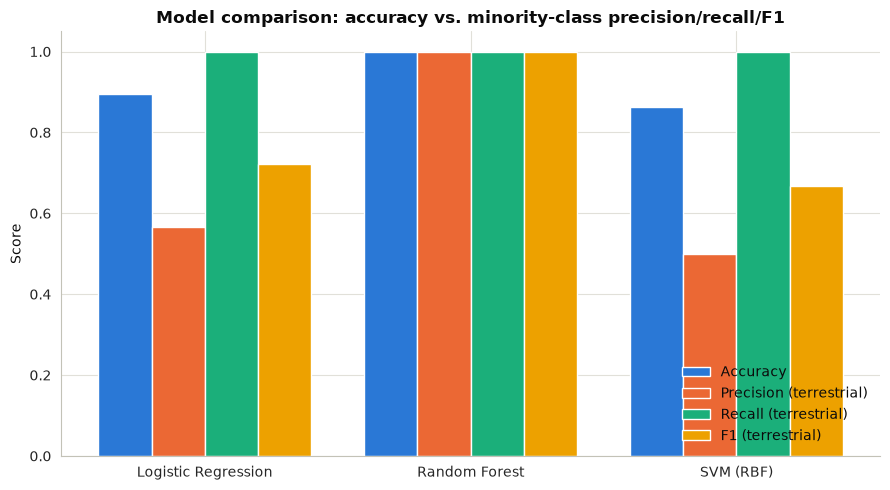

In [13]:
metric_colors = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]  # fixed categorical order, slots 1-4
metrics = results_df.columns.tolist()
model_names = results_df.index.tolist()

x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(9, 5))
for i, metric in enumerate(metrics):
    offset = (i - (len(metrics) - 1) / 2) * width
    bars = ax.bar(x + offset, results_df[metric], width, label=metric, color=metric_colors[i])

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Model comparison: accuracy vs. minority-class precision/recall/F1")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 8. Takeaways

See `README.md` for the full write-up of methodology, the class-imbalance
handling, and a discussion of these results.
